In [3]:
import os
import json
import pickle
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [4]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
MODELS     = CONFIGS['experiments']
SPLIT      = 'test'

SR_GAUSS_FIELDVARS = MODELS['sr']['runs']['sr_gauss']['fieldvars']
NN_SEEDS           = MODELS['nn']['seeds']

COLORS = {}
LABELS = {}
for name,cfg in MODELS['sr']['optimizedeqs'].items():
    COLORS[name] = cfg['color']
    LABELS[name] = cfg['description']

MINSAMP = 30
NBINS   = 40

In [5]:
def kernel_integrate(fields,weights,dsig,mask=None):
    w = fields * weights[None,:,:] * dsig[None,None,:]
    if mask is not None:
        w = w * mask[:,None,:]
    return w.sum(axis=2)

def to_phys(srout):
    return np.expm1(tpstd * np.maximum(0.0,np.asarray(srout,dtype=float)))

def bin1d(x,z,nbins=NBINS,minsamp=MINSAMP,plo=1,phi=99):
    finite = np.isfinite(x) & np.isfinite(z)
    x,z    = x[finite],z[finite]
    edges  = np.unique(np.percentile(x,np.linspace(plo,phi,nbins+1)))
    n      = len(edges)-1
    xi     = np.clip(np.digitize(x,edges)-1,0,n-1)
    means  = np.full(n,np.nan); counts = np.zeros(n,int)
    for i in range(n):
        sel = xi==i; counts[i] = sel.sum()
        if counts[i]>=minsamp: means[i] = z[sel].mean()
    return edges,0.5*(edges[:-1]+edges[1:]),means,counts

def bin2d(x,y,z,xedges,yedges,minsamp=MINSAMP):
    finite  = np.isfinite(x) & np.isfinite(y) & np.isfinite(z)
    x,y,z   = x[finite],y[finite],z[finite]
    nx,ny   = len(xedges)-1,len(yedges)-1
    xi      = np.clip(np.digitize(x,xedges)-1,0,nx-1)
    yi      = np.clip(np.digitize(y,yedges)-1,0,ny-1)
    idx     = yi*nx+xi
    counts  = np.bincount(idx,minlength=nx*ny).reshape(ny,nx)
    sums    = np.bincount(idx,weights=z,minlength=nx*ny).reshape(ny,nx)
    return np.where(counts>=minsamp,sums/counts,np.nan),counts

def prange(arr,lo=1,hi=99):
    a = arr[np.isfinite(arr)]
    return float(np.percentile(a,lo)),float(np.percentile(a,hi))

In [6]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
tpmean = float(STATS['tp_mean'])
tpstd  = float(STATS['tp_std'])

with xr.open_dataset(os.path.join(SPLITSDIR,f'norm_{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime = ds.sizes['time']; nlat = ds.sizes['lat']; nlon = ds.sizes['lon']
    nsig  = ds.sizes.get('sig',1)
    refshape = (ntime,nlat,nlon)
    lats = ds.lat.values; lons = ds.lon.values
    dsig = ds['dsig'].values
    levmin,levmax = CONFIGS['domain']['levrange']
    sigcoords = (ds.coords['sig'].values if 'sig' in ds.coords
                 else np.linspace(levmin/1000,levmax/1000,nsig))
    farrs      = [ds[v].transpose('time','lat','lon','sig').values.reshape(-1,nsig)
                  for v in SR_GAUSS_FIELDVARS]
    fieldstack = np.stack(farrs,axis=1)
    surfmask   = (ds['surfmask'].transpose('time','lat','lon','sig').values.reshape(-1,nsig)
                  if 'surfmask' in ds else None)

kwlist = []
for seed in NN_SEEDS:
    wpath = os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc')
    if os.path.exists(wpath):
        with xr.open_dataset(wpath,engine='h5netcdf') as wds:
            kwlist.append(wds['k'].values)
            if 'sig' in wds.coords and len(kwlist)==1:
                sigcoords = wds.coords['sig'].values

if kwlist:
    ki          = np.mean([kernel_integrate(fieldstack,kw,dsig,surfmask) for kw in kwlist],axis=0)
    rhk         = ki[:,0]
    thetaek     = ki[:,1]
    thetaestark = ki[:,2]
else:
    rhk         = fieldstack[:,0,:].mean(axis=1)
    thetaek     = fieldstack[:,1,:].mean(axis=1)
    thetaestark = fieldstack[:,2,:].mean(axis=1)

with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    trueflat = ds.tp.transpose('time','lat','lon').values.ravel()
    if 'lf' in ds:
        lf2d       = ds['lf'].squeeze() if 'time' not in ds['lf'].dims else ds['lf'].isel(time=0)
        landmask2d = (lf2d.values>=0.5)
        landflat   = np.broadcast_to(landmask2d[None],refshape).ravel().copy()
    else:
        landmask2d = landflat = None

regpath = os.path.join(MODELSDIR,'sr','optimized_equations.pkl')
if os.path.exists(regpath):
    with open(regpath,'rb') as f:
        SR_REGISTRY = pickle.load(f)
else:
    SR_REGISTRY = {}

valid = (np.isfinite(trueflat) & np.isfinite(rhk) &
         np.isfinite(thetaek) & np.isfinite(thetaestark))
print(f'Valid samples: {valid.sum():,}')

Valid samples: 1,437,408


In [7]:
if 'sr_med' in SR_REGISTRY:
    c = SR_REGISTRY['sr_med']['constants']
    am,bm,cm = c['a'],c['b'],c['c']
    Mall = rhk[valid]; Iall = thetaek[valid]-bm*thetaestark[valid]-cm
    Pall = trueflat[valid]
    moist = Mall>=Iall; insta = ~moist
    print(f'Moisture-ctrl (M>=I): {100*moist.mean():.1f}%  mean P={Pall[moist].mean():.3f} mm')
    print(f'Instability   (I>M):  {100*insta.mean():.1f}%  mean P={Pall[insta].mean():.3f} mm')
    if landflat is not None:
        lv = landflat[valid].astype(bool)
        for lbl,lmask in [('Land',lv),('Ocean',~lv)]:
            for rlbl,rmask in [('Moisture',moist),('Instability',insta)]:
                m = lmask & rmask
                print(f'  {lbl} {rlbl}: {100*m.sum()/lmask.sum():.1f}%  mean P={Pall[m].mean():.3f}')

Moisture-ctrl (M>=I): 24.7%  mean P=1.079 mm
Instability   (I>M):  75.3%  mean P=0.668 mm
  Land Moisture: 37.8%  mean P=1.398
  Land Instability: 62.2%  mean P=0.833
  Ocean Moisture: 19.1%  mean P=0.812
  Ocean Instability: 80.9%  mean P=0.615


In [9]:
# if 'sr_med' not in SR_REGISTRY:
#     print('sr_med not in registry — skipping')
# else:
#     c = SR_REGISTRY['sr_med']['constants']
#     am,bm,cm = c['a'],c['b'],c['c']
#     M = rhk[valid]; I = thetaek[valid]-bm*thetaestark[valid]-cm
#     P = trueflat[valid]
#     Mlo,Mhi = prange(M); Ilo,Ihi = prange(I)
#     axlo = min(Mlo,Ilo); axhi = max(Mhi,Ihi)
#     NB = 35
#     xe = np.linspace(Mlo,Mhi,NB+1); ye = np.linspace(Ilo,Ihi,NB+1)
#     xcen = 0.5*(xe[:-1]+xe[1:]); ycen = 0.5*(ye[:-1]+ye[1:])
#     obsbin,_  = bin2d(M,I,P,xe,ye)
#     srbin,_   = bin2d(M,I,to_phys(am*np.maximum(M,I)**3),xe,ye)
#     density   = np.log10(np.histogram2d(M,I,bins=[xe,ye])[0].T.clip(1))
#     vmax      = float(np.nanpercentile(np.r_[obsbin[~np.isnan(obsbin)],srbin[~np.isnan(srbin)]],97))
#     NG = 200
#     Mg,Ig       = np.meshgrid(np.linspace(Mlo,Mhi,NG),np.linspace(Ilo,Ihi,NG))
#     Pgrid       = to_phys(am*np.maximum(Mg,Ig)**3)
#     Mfull       = rhk.reshape(refshape)
#     Ifull       = (thetaek-bm*thetaestark-cm).reshape(refshape)
#     fracmoist2d = (Mfull>=Ifull).mean(axis=0)
#     latlim      = (float(lats.min()),float(lats.max()))
#     lonlim      = (float(lons.min()),float(lons.max()))
#     xlabelM = r'$\widehat{\mathrm{RH}}$'
#     ylabelI = r'$\widehat{\theta_e} - \gamma\widehat{\theta_e^*} - \eta$'
#     kw    = dict(cmap='ColdHot_r',cmap_kw={'left':0.5},vmin=0,vmax=4,levels=10,extend='max')
#     kwmap = dict(coast=True,lonlim=lonlim,lonlines=5,lonlabels='b',latlim=latlim,latlines=[10,15,20],latlabels='l',grid=False)
#     fig,axs = pplt.subplots([[1,2],[3,4]],figwidth=6.5,hratios=(2,1),proj={4:'cyl'},share=False)
#     m0 = axs[0].pcolormesh(np.linspace(Mlo,Mhi,NG),np.linspace(Ilo,Ihi,NG),Pgrid,**kw)
#     axs[0].plot([axlo,axhi],[axlo,axhi],'k--',lw=1)
#     axs[0].text(Mhi-0.05*(Mhi-Mlo),Ilo+0.08*(Ihi-Ilo),'moisture-dominated',ha='right',va='bottom')
#     axs[0].text(Mlo+0.05*(Mhi-Mlo),Ihi-0.08*(Ihi-Ilo),'instability-dominated',ha='left',va='top')
#     axs[0].format(xlabel=xlabelM,ylabel=ylabelI,title='SR-MED',xlim=(Mlo,Mhi),ylim=(Ilo,Ihi))
#     m1 = axs[1].pcolormesh(xcen,ycen,obsbin,**kw)
#     axs[1].plot([axlo,axhi],[axlo,axhi],'k--',lw=1)
#     axs[1].text(Mhi-0.05*(Mhi-Mlo),Ilo+0.08*(Ihi-Ilo),'moisture-dominated',ha='right',va='bottom')
#     axs[1].text(Mlo+0.05*(Mhi-Mlo),Ihi-0.08*(Ihi-Ilo),'instability-dominated',ha='left',va='top')
#     axs[1].format(xlabel=xlabelM,ylabel=ylabelI,title='Observed',xlim=(Mlo,Mhi),ylim=(Ilo,Ihi),facecolor='gray1')
#     fig.colorbar(m0,ax=axs[:2],loc='r',label='Precipitation (mm)')
#     m2 = axs[2].pcolormesh(xcen,ycen,density,cmap='Grays',vmin=0)
#     axs[2].plot([axlo,axhi],[axlo,axhi],'k--',lw=0.8)
#     axs[2].format(xlabel=xlabelM,ylabel=ylabelI,title='Sample Density',xlim=(Mlo,Mhi),ylim=(Ilo,Ihi))
#     fig.colorbar(m2,ax=axs[2],loc='b',label='log$_{10}$(N)')
#     m3 = axs[3].pcolormesh(lons,lats,fracmoist2d,cmap='ColdHot_r',vmin=0,vmax=1)
#     axs[3].format(title='Moisture-Dominated Fraction',**kwmap)
#     fig.colorbar(m3,ax=axs[3],loc='b',label='Fraction (Moisture \u2265 Instability)')
#     fig.format(abc=True)
#     pplt.show()
#     fig.save('../figs/fig_4.jpg')

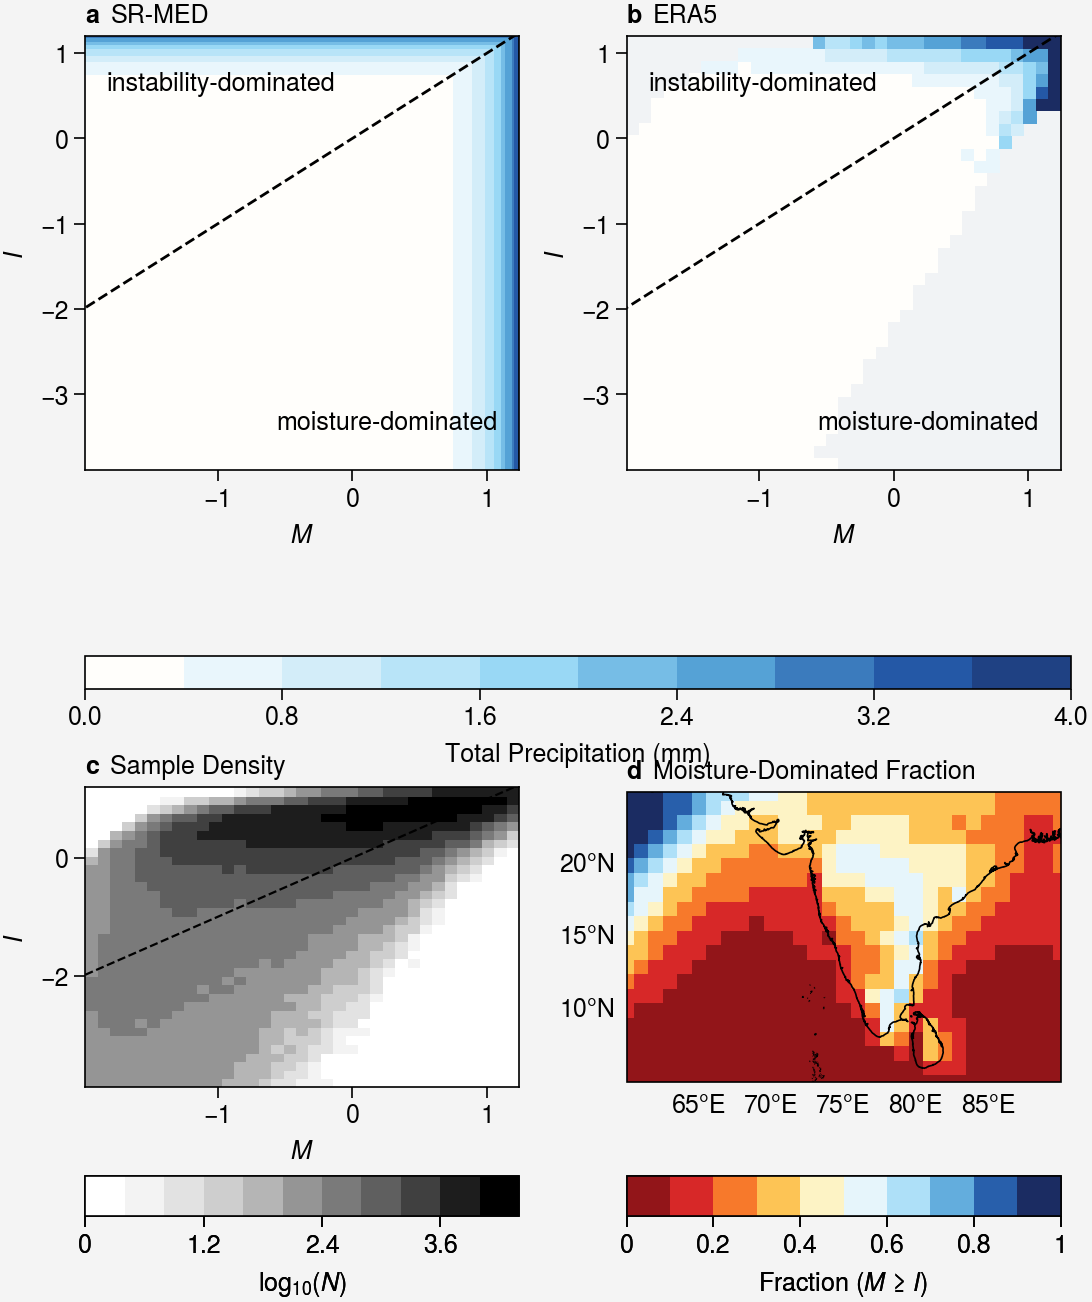

In [20]:
if 'sr_med' not in SR_REGISTRY:
    print('sr_med not in registry — skipping')
else:
    c = SR_REGISTRY['sr_med']['constants']
    am,bm,cm = c['a'],c['b'],c['c']
    M = rhk[valid]
    I = thetaek[valid]-bm*thetaestark[valid]-cm
    P = trueflat[valid]
    Mlo,Mhi = prange(M)
    Ilo,Ihi = prange(I)
    axlo = min(Mlo,Ilo)
    axhi = max(Mhi,Ihi)
    NB = 35
    xe = np.linspace(Mlo,Mhi,NB+1)
    ye = np.linspace(Ilo,Ihi,NB+1)
    xcen = 0.5*(xe[:-1]+xe[1:])
    ycen = 0.5*(ye[:-1]+ye[1:])
    obsbin,_ = bin2d(M,I,P,xe,ye)
    srbin,_ = bin2d(M,I,to_phys(am*np.maximum(M,I)**3),xe,ye)
    density = np.log10(np.histogram2d(M,I,bins=[xe,ye])[0].T.clip(1))
    vmax = float(np.nanpercentile(np.r_[obsbin[~np.isnan(obsbin)],srbin[~np.isnan(srbin)]],97))
    NG = 200
    Mg,Ig = np.meshgrid(np.linspace(Mlo,Mhi,NG),np.linspace(Ilo,Ihi,NG))
    Pgrid = to_phys(am*np.maximum(Mg,Ig)**3)
    Mfull = rhk.reshape(refshape)
    Ifull = (thetaek-bm*thetaestark-cm).reshape(refshape)
    fracmoist2d = (Mfull>=Ifull).mean(axis=0)
    latlim = (float(lats.min()),float(lats.max()))
    lonlim = (float(lons.min()),float(lons.max()))
    midlat = np.radians((latlim[0]+latlim[1])/2)
    mapaspect = np.cos(midlat)*(lonlim[1]-lonlim[0])/(latlim[1]-latlim[0])
    c_asp = (Mhi-Mlo)/((Ihi-Ilo)*mapaspect)
    xlabelM = r'$\mathit{M}$'
    ylabelI = r'$\mathit{I}$'
    kw = dict(cmap='ColdHot_r',cmap_kw={'left':0.5},vmin=0,vmax=4,levels=10,extend='max')
    kwmap = dict(coast=True,lonlim=lonlim,lonlines=5,lonlabels='b',latlim=latlim,latlines=[10,15,20],latlabels='l',grid=False)
    fig,axs = pplt.subplots([[1,2],[3,4]],figwidth=5.5,proj={4:'cyl'},share=False,hspace=10)

    m0 = axs[0].pcolormesh(np.linspace(Mlo,Mhi,NG),np.linspace(Ilo,Ihi,NG),Pgrid,**kw)
    axs[0].plot([axlo,axhi],[axlo,axhi],'k--',lw=1)
    axs[0].text(Mhi-0.05*(Mhi-Mlo),Ilo+0.08*(Ihi-Ilo),'moisture-dominated',ha='right',va='bottom')
    axs[0].text(Mlo+0.05*(Mhi-Mlo),Ihi-0.08*(Ihi-Ilo),'instability-dominated',ha='left',va='top')
    axs[0].format(xlabel=xlabelM,ylabel=ylabelI,title='SR-MED',xlim=(Mlo,Mhi),ylim=(Ilo,Ihi))

    m1 = axs[1].pcolormesh(xcen,ycen,obsbin,**kw)
    axs[1].plot([axlo,axhi],[axlo,axhi],'k--',lw=1)
    axs[1].text(Mhi-0.05*(Mhi-Mlo),Ilo+0.08*(Ihi-Ilo),'moisture-dominated',ha='right',va='bottom')
    axs[1].text(Mlo+0.05*(Mhi-Mlo),Ihi-0.08*(Ihi-Ilo),'instability-dominated',ha='left',va='top')
    axs[1].format(xlabel=xlabelM,ylabel=ylabelI,title='ERA5',xlim=(Mlo,Mhi),ylim=(Ilo,Ihi),facecolor='gray1')

    m2 = axs[2].pcolormesh(xcen,ycen,density,cmap='Grays',vmin=0)
    axs[2].plot([axlo,axhi],[axlo,axhi],'k--',lw=0.8)
    axs[2].format(xlabel=xlabelM,ylabel=ylabelI,title='Sample Density',xlim=(Mlo,Mhi),ylim=(Ilo,Ihi),aspect=c_asp)
    axs[2].colorbar(m2,loc='b',label=r'log$_{10}$($\mathit{N}$)')

    m3 = axs[3].pcolormesh(lons,lats,fracmoist2d,cmap='ColdHot_r',vmin=0,vmax=1)
    axs[3].format(title='Moisture-Dominated Fraction',**kwmap)
    axs[3].colorbar(m3,loc='b',ticks=0.2,label=r'Fraction ($\mathit{M}$ ≥ $\mathit{I}$)')

    fig.format(abc=True,titleloc='l')
    fig.canvas.draw()

    left   = min(axs[0].get_position().x0,axs[1].get_position().x0)
    right  = max(axs[0].get_position().x1,axs[1].get_position().x1)
    bottom_toprow  = min(axs[0].get_position().y0,axs[1].get_position().y0)
    top_bottomrow  = max(axs[2].get_position().y1,axs[3].get_position().y1)
    gap        = bottom_toprow - top_bottomrow
    cbar_h     = 0.025
    cbar_pad   = 0.3 * gap
    cbar_y     = top_bottomrow + cbar_pad

    cax = fig.add_axes([left, cbar_y, right-left, cbar_h])
    cb  = fig.colorbar(m0,cax=cax,orientation='horizontal',label='Total Precipitation (mm)')
    cb.ax.tick_params(labelsize=9)

    pplt.show()
    fig.save('../figs/fig_4.jpg')